In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

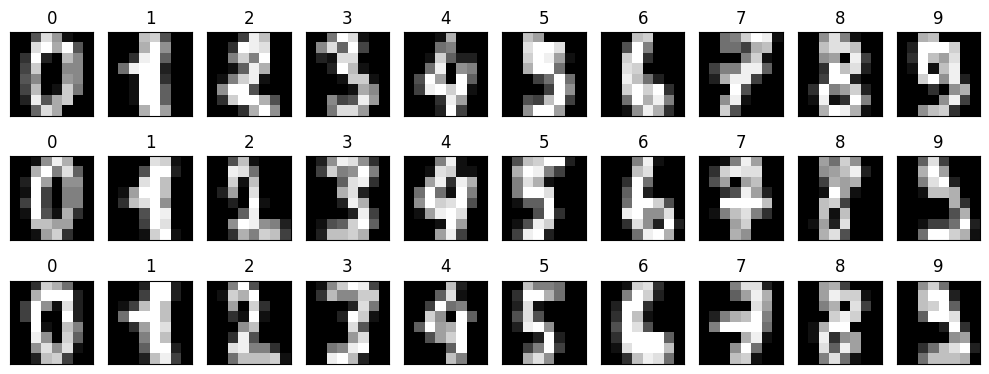

In [2]:
X, y = load_digits(return_X_y=True, as_frame=True, n_class=10)

plt.figure(figsize=(10, 4))
for i in range(30):
    plt.subplot(3, 10, i + 1)
    image = X.loc[i, :].to_numpy()
    plt.imshow(image.reshape(8, 8), cmap=plt.cm.gray)
    plt.title(y[i])
    plt.xticks(())
    plt.yticks(())
plt.tight_layout()
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=0, stratify=y
)

In [3]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_train_pred_lda = lda.predict(X_train)
y_test_pred_lda = lda.predict(X_test)

lda_train_acc = accuracy_score(y_train, y_train_pred_lda)
lda_test_acc = accuracy_score(y_test, y_test_pred_lda)

print("(a) LDA")
print("Training accuracy:", lda_train_acc)
print("Test accuracy:", lda_test_acc)

(a) LDA
Training accuracy: 0.9699331848552338
Test accuracy: 0.946607341490545


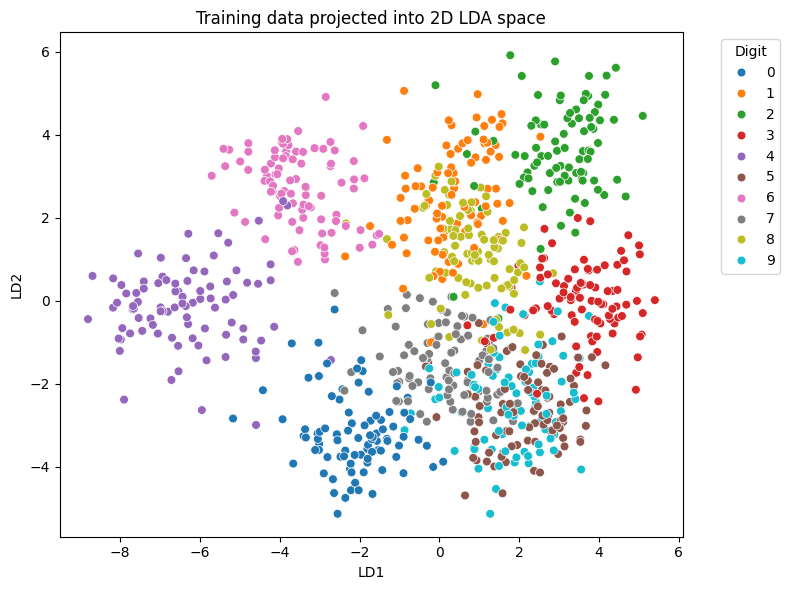

In [4]:
lda_2d = LinearDiscriminantAnalysis(n_components=2)
X_train_lda_2d = lda_2d.fit_transform(X_train, y_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_lda_2d[:, 0],
    y=X_train_lda_2d[:, 1],
    hue=y_train,
    palette="tab10",
    s=40
)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Training data projected into 2D LDA space")
plt.legend(title="Digit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

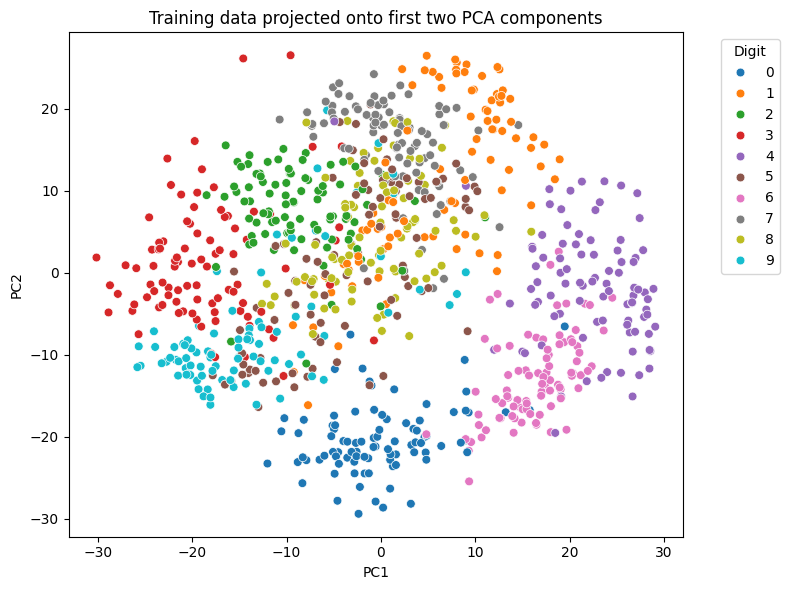

In [7]:
pca = PCA(n_components=2)
X_train_pca_2d = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_pca_2d[:, 0],
    y=X_train_pca_2d[:, 1],
    hue=y_train,
    palette="tab10",
    s=40
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Training data projected onto first two PCA components")
plt.legend(title="Digit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
qda = QuadraticDiscriminantAnalysis(reg_param=0.0)
qda.fit(X_train, y_train)

y_train_pred_qda = qda.predict(X_train)
y_test_pred_qda = qda.predict(X_test)

qda_train_acc = accuracy_score(y_train, y_train_pred_qda)
qda_test_acc = accuracy_score(y_test, y_test_pred_qda)

print("\n(d) QDA without regularisation")
print("Training accuracy:", qda_train_acc)
print("Test accuracy:", qda_test_acc)


(d) QDA without regularisation
Training accuracy: 0.9487750556792873
Test accuracy: 0.8531701890989989


/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The 

In [9]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_train_pred_gnb = gnb.predict(X_train)
y_test_pred_gnb = gnb.predict(X_test)

gnb_train_acc = accuracy_score(y_train, y_train_pred_gnb)
gnb_test_acc = accuracy_score(y_test, y_test_pred_gnb)

print("\n(f) Gaussian Naive Bayes")
print("Training accuracy:", gnb_train_acc)
print("Test accuracy:", gnb_test_acc)


(f) Gaussian Naive Bayes
Training accuracy: 0.8530066815144766
Test accuracy: 0.8286985539488321


In [10]:
print(lda_train_acc)
print(lda_test_acc)

0.9699331848552338
0.946607341490545
